In [25]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт модулей для машинного обучения и предобработки
from sklearn.model_selection import train_test_split  # Разделение данных на обучающую и тестовую выборки
from sklearn.preprocessing import StandardScaler  # Масштабирование данных
from sklearn.ensemble import AdaBoostClassifier  # Алгоритм AdaBoost
from sklearn.tree import DecisionTreeClassifier  # Базовый Estimator (дерево решений)
from sklearn.impute import SimpleImputer  # Заполнение пропущенных значений в данных
from sklearn.metrics import (  # Метрики оценки качества модели
    classification_report, confusion_matrix, accuracy_score, roc_curve, auc
)

In [26]:

# 1. Загрузка данных
# Загрузка датасета из файла CSV
data = pd.read_csv("../data/breast_cancer_data.csv")
# Удаление столбцов с названием 'Unnamed', если они присутствуют
data = data.loc[:, ~data.columns.str.contains('Unnamed')]

# 2. Предварительная обработка данных
# Удаление столбца 'id', так как он не имеет значимости для модели
if 'id' in data.columns:
    data.drop(columns=['id'], inplace=True)

# Преобразование целевой переменной 'diagnosis': M (злокачественная) -> 1, B (доброкачественная) -> 0
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Определение признаков (X - объясняющие переменные) и целевой переменной (y - целевой столбец)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Заполнение пропущенных значений в объясняющих переменных медианными значениями
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [27]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

print(data.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          1        17.99         10.38          122.80     1001.0          0.11840   
1          1        20.57         17.77          132.90     1326.0          0.08474   
2          1        19.69         21.25          130.00     1203.0          0.10960   
3          1        11.42         20.38           77.58      386.1          0.14250   
4          1        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  fractal_dimension_mean  \
0           0.27760          0.3001              0.14710         0.2419                 0.07871   
1           0.07864          0.0869              0.07017         0.1812                 0.05667   
2           0.15990          0.1974              0.12790         0.2069                 0.05999   
3           0.28390          0.2414              0.10520         0.2597          

In [28]:

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [29]:

print(data.describe())

        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  smoothness_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000       569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104         0.096360   
std      0.483918     3.524049      4.301036       24.298981   351.914129         0.014064   
min      0.000000     6.981000      9.710000       43.790000   143.500000         0.052630   
25%      0.000000    11.700000     16.170000       75.170000   420.300000         0.086370   
50%      0.000000    13.370000     18.840000       86.240000   551.100000         0.095870   
75%      1.000000    15.780000     21.800000      104.100000   782.700000         0.105300   
max      1.000000    28.110000     39.280000      188.500000  2501.000000         0.163400   

       compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
count        569.000000      569.000000           569.000000     569.00000

In [30]:

# 3. Разделение данных на обучающую и тестовую выборки
# Данные делятся в пропорции 70/30 с фиксированным random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [31]:

# 4. Масштабирование признаков
# Нормализация данных с помощью StandardScaler (важно для большинства моделей машинного обучения)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Инициализация базового классификатора ("пень", stump)
# Используется DecisionTreeClassifier с глубиной 1 в качестве слабого классификатора
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# 6. Инициализация и обучение модели AdaBoostClassifier
# Конфигурация модели: базовый классификатор, 50 слабых оценщиков и фиксированная скорость обучения 1.0
ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
# Обучение модели на масштабированных тренировочных данных
ada.fit(X_train_scaled, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [32]:

# 7. Предсказание и оценка модели
# Выполнение предсказания на тестовых данных
y_pred = ada.predict(X_test_scaled)

# Вывод отчёта по классификации (precision, recall, f1-score) для оценки качества модели
print("Отчет по классификации:")
print(classification_report(y_test, y_pred, digits=4))

Отчет по классификации:
              precision    recall  f1-score   support

           0     0.9813    0.9722    0.9767       108
           1     0.9531    0.9683    0.9606        63

    accuracy                         0.9708       171
   macro avg     0.9672    0.9702    0.9687       171
weighted avg     0.9709    0.9708    0.9708       171



In [33]:

# Вывод матрицы ошибок для анализа правильных и ошибочных предсказаний
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))


Матрица ошибок:
[[105   3]
 [  2  61]]


In [34]:

# Вывод точности (Accuracy) модели
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))


Accuracy: 0.9708


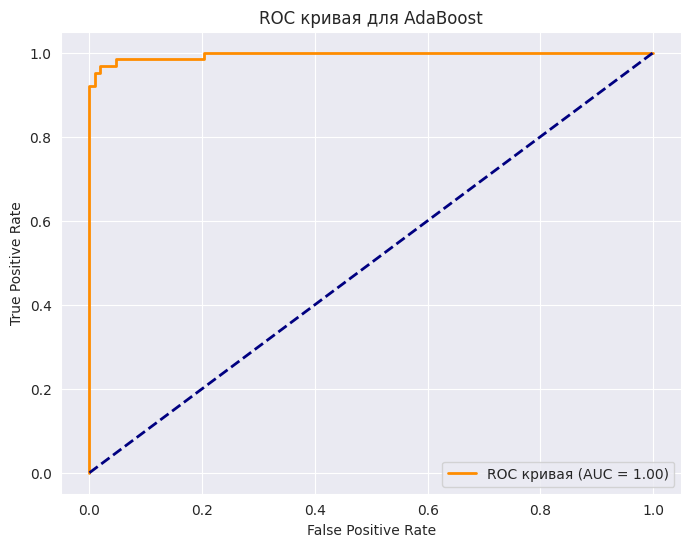

In [35]:

# 8. Визуализация ROC-кривой
# Расчёт вероятностей для положительного класса и ROC-кривой
y_proba = ada.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Построение ROC-кривой для визуальной оценки качества модели
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая для AdaBoost')
plt.legend(loc="lower right")
plt.show()

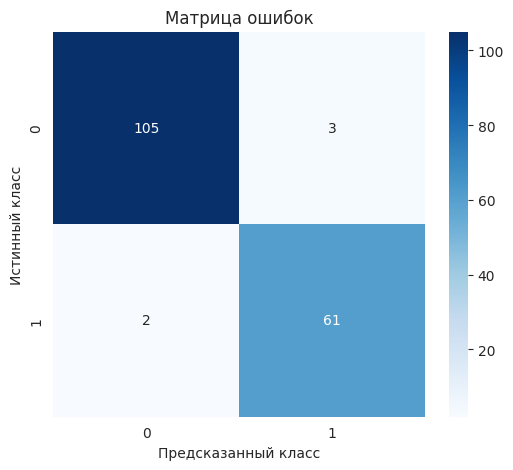

In [36]:

# Визуализация матрицы ошибок
# Используется heatmap для отображения количества ошибок и успешных предсказаний
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")
plt.show()


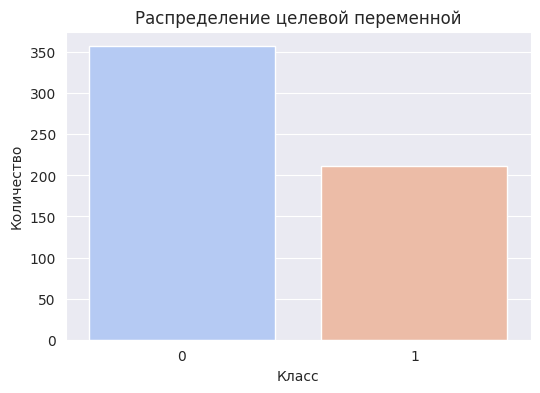

In [37]:


# 9. Распределение целевой переменной
# Построение гистограммы для анализа пропорции классов в данных
plt.figure(figsize=(6, 4))
sns.countplot(x=y,hue=y, palette="coolwarm",legend=False)
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.title("Распределение целевой переменной")
plt.show()

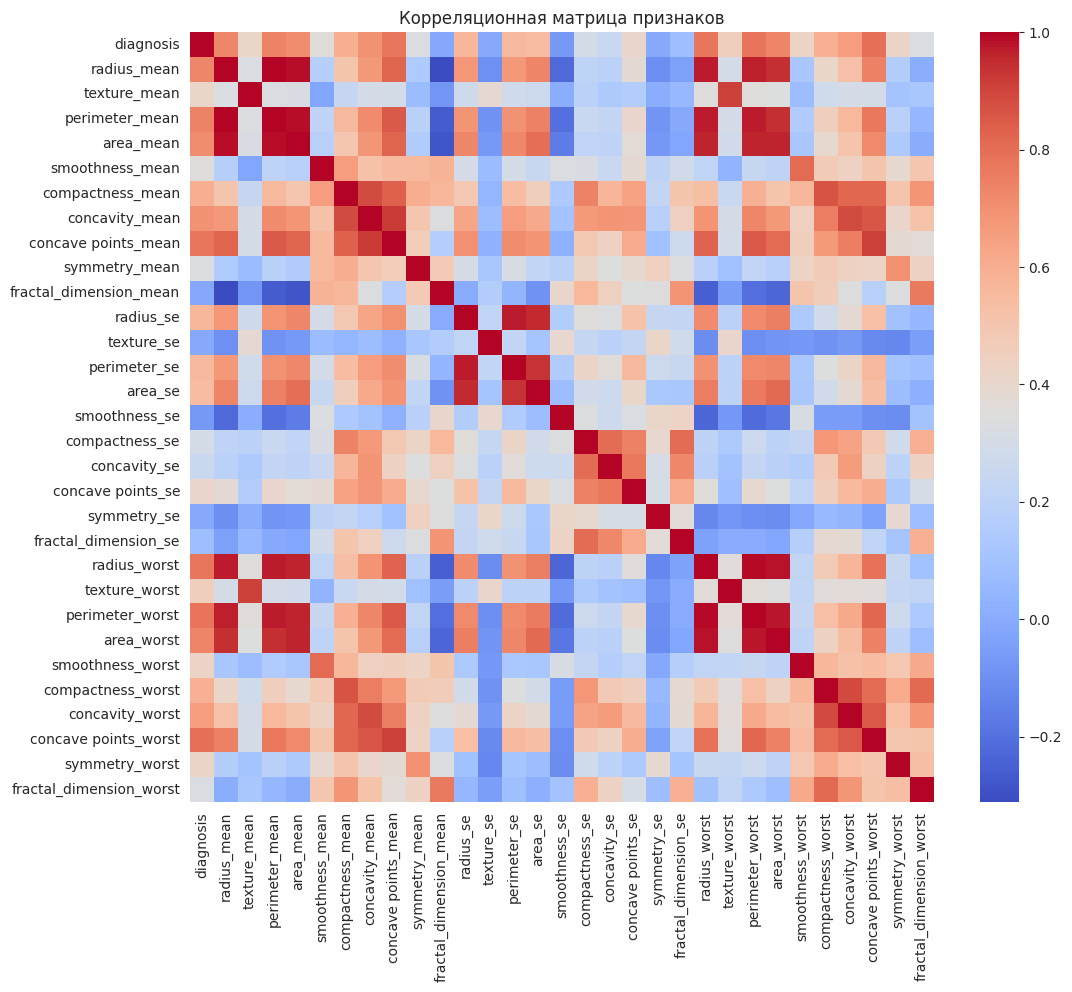

In [38]:

# 10. Корреляционная матрица
# Визуализация корреляционной матрицы для нахождения взаимосвязей между признаками
plt.figure(figsize=(12, 10))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Корреляционная матрица признаков")
plt.show()

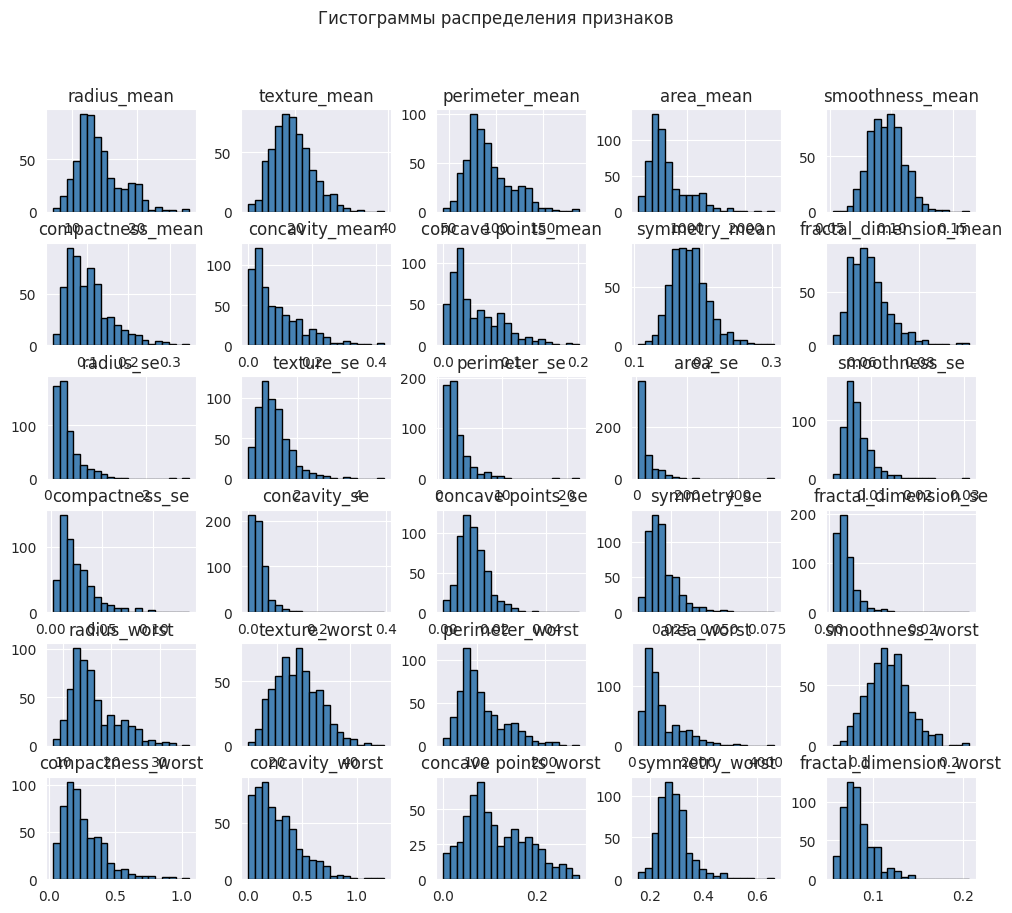

In [39]:

# 11. Гистограммы распределения признаков
# Построение гистограмм для изучения распределения числовых признаков
X.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Гистограммы распределения признаков")
plt.show()

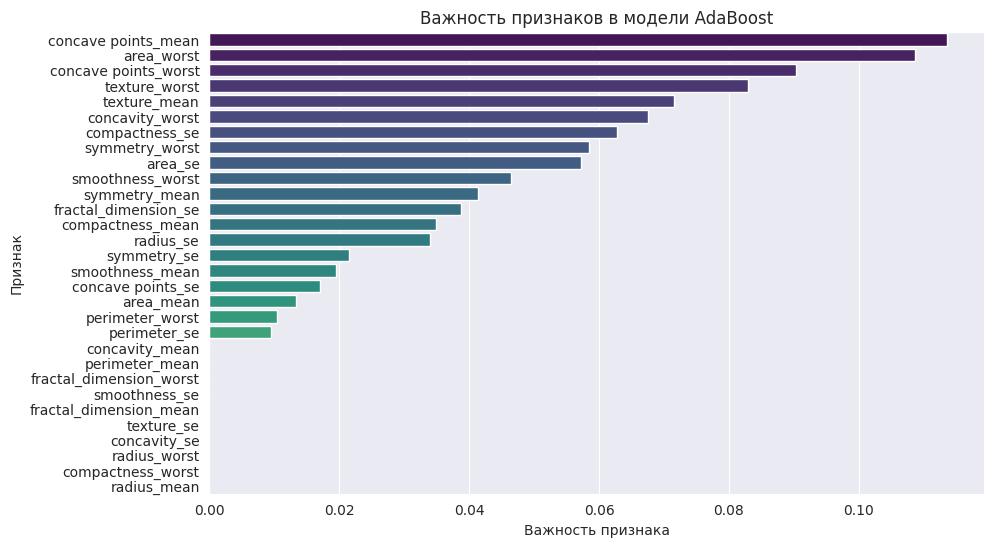

In [40]:

# 12. Важность признаков
# Вычисление важности признаков по модели AdaBoost
feature_importances = ada.feature_importances_
features = X.columns
# Сортировка по значимости
sorted_indices = np.argsort(feature_importances)[::-1]

# Визуализация важности признаков (барплот для наглядности)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[sorted_indices], y=features[sorted_indices], hue=features[sorted_indices], palette="viridis", legend=False)
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.title("Важность признаков в модели AdaBoost")
plt.show()

In [41]:

# Вывод:
# 1. Код корректно реализует полный цикл работы алгоритма AdaBoost с использованием decision stumps.
# 2. На этапе предобработки данные очищаются, нормализуются и корректно разделяются на обучающую и тестовую выборки.
# 3. Метрики (precision, recall, f1-score, confusion matrix) показывают высокое качество модели:
#    - Accuracy: 97.08%
#    - Небольшое количество ошибок в матрице ошибок подтверждает хорошую работу модели.
# 4. Визуализации (ROC-кривая, распределение целевой переменной, корреляционная матрица, гистограммы распределения признаков,
#    важность признаков) позволяют детально проанализировать данные и оценить модель с разных сторон.
# 5. Полученные результаты являются очень хорошими для данного датасета, что свидетельствует о корректности как данных, так и модели.
#    Если цель – демонстрация работы алгоритма, то датасет выбран удачно. При необходимости можно провести дополнительные эксперименты
#    с другими наборами данных для проверки устойчивости модели.
